# Table of Contents

1. [Setup and Reusable Helper Functions](#1-setup-and-reusable-helper-functions)
2. [Data Ingestion and Quality Checks](#2-data-ingestion-and-quality-checks)
3. [Question 1 — Total Pageviews and Pageviews per Day](#3-question-1--total-pageviews-and-pageviews-per-day)
4. [Question 2 — Other Recorded Events](#4-question-2--other-recorded-events)
5. [Question 3 — Countries That Generated Pageviews](#5-question-3--countries-that-generated-pageviews)
6. [Question 4 — Overall Click Rate](#6-question-4--overall-click-rate)
7. [Question 5 — Distribution of Click Rate Across Links](#7-question-5--distribution-of-click-rate-across-links)
8. [Question 6 — Relationship Between Clicks and Previews](#8-question-6--relationship-between-clicks-and-previews)
9. [Final Insights and Business Interpretation](#9-final-insights-and-business-interpretation)

## 1. Setup and reusable helper functions

The dataset is small enough for in-memory Pandas analysis. The helper functions below centralize validation, link-level aggregation, p-value formatting, confidence intervals, and effect-size interpretation.

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from IPython.display import Markdown, display
from scipy import stats

%matplotlib inline

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

EXPECTED_EVENTS = ["pageview", "click", "preview"]


def build_link_metrics(data: pd.DataFrame) -> pd.DataFrame:
    """Return exactly one row per link with pageview, click, and preview counts."""
    event_counts = pd.crosstab(data["linkid"], data["event"])
    event_counts = event_counts.reindex(columns=EXPECTED_EVENTS, fill_value=0)
    event_counts = event_counts.rename(
        columns={"pageview": "pageviews", "click": "clicks", "preview": "previews"}
    ).astype("int64")

    event_counts["has_pageview"] = event_counts["pageviews"].gt(0)
    event_counts["has_click"] = event_counts["clicks"].gt(0)
    event_counts["has_preview"] = event_counts["previews"].gt(0)

    # Rates are undefined when pageviews are zero. Keep NaN rather than dividing by zero.
    valid_denominator = event_counts["pageviews"].gt(0)
    event_counts["click_rate"] = np.where(
        valid_denominator,
        event_counts["clicks"] / event_counts["pageviews"],
        np.nan,
    )
    event_counts["preview_rate"] = np.where(
        valid_denominator,
        event_counts["previews"] / event_counts["pageviews"],
        np.nan,
    )
    return event_counts


def format_p_value(p_value: float) -> str:
    """Format very small p-values without reporting floating-point underflow as p = 0."""
    if p_value == 0:
        return "< 1e-300"
    if p_value < 0.001:
        return f"{p_value:.2e}"
    return f"{p_value:.4f}"


def correlation_effect_label(value: float) -> str:
    """Conventional, context-dependent magnitude labels for correlation-like effects."""
    magnitude = abs(value)
    if magnitude < 0.10:
        return "negligible"
    if magnitude < 0.30:
        return "small"
    if magnitude < 0.50:
        return "moderate"
    return "large"


def pearson_confidence_interval(r: float, n: int, confidence: float = 0.95) -> tuple[float, float]:
    """Approximate Pearson-r confidence interval using Fisher's z transformation."""
    if n <= 3:
        return (np.nan, np.nan)
    r = float(np.clip(r, -0.999999999, 0.999999999))
    z = np.arctanh(r)
    standard_error = 1 / np.sqrt(n - 3)
    critical_value = stats.norm.ppf(1 - (1 - confidence) / 2)
    return tuple(np.tanh([z - critical_value * standard_error,
                          z + critical_value * standard_error]))


def odds_ratio_confidence_interval(table: np.ndarray, confidence: float = 0.95) -> tuple[float, float]:
    """Wald confidence interval for a 2x2 odds ratio; applies a 0.5 correction if needed."""
    values = table.astype(float)
    if (values == 0).any():
        values += 0.5
    a, b, c, d = values.ravel()
    odds_ratio = (a * d) / (b * c)
    standard_error = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
    critical_value = stats.norm.ppf(1 - (1 - confidence) / 2)
    lower = np.exp(np.log(odds_ratio) - critical_value * standard_error)
    upper = np.exp(np.log(odds_ratio) + critical_value * standard_error)
    return float(lower), float(upper)


## 2. Data ingestion and quality checks

An exact duplicate row is **not automatically a duplicate event here**. The file has no event ID, user ID, session ID, or timestamp. Two identical rows can therefore represent two legitimate events with the same day, location, content, and link. We audit exact duplicates but do not remove them from the primary analysis.

In [35]:
df = pd.read_csv('traffic.csv')

quality_summary = pd.Series(
    {
        "rows": len(df),
        "columns": df.shape[1],
        "date_start": df["date"].min(),
        "date_end": df["date"].max(),
        "days_observed": df["date"].nunique(),
        "unique_links": df["linkid"].nunique(),
        "exact_duplicate_rows": int(df.duplicated().sum()),
    },
    name="value",
).to_frame()

display(quality_summary)
print('\n')

display(Markdown("**Null counts by column**"))
display(df.isna().sum().rename("null_count").to_frame())
print('\n')

display(Markdown("**Sample records**"))
display(df.head())

,value
rows,226278
columns,9
date_start,2021-08-19
date_end,2021-08-25
days_observed,7
unique_links,3839
exact_duplicate_rows,103711


**Null counts by column**

,null_count
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


**Sample records**

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [36]:
# Computing link metrics using helper function
link_metrics = build_link_metrics(df)

display(Markdown("**Link Metrics**"))
display(link_metrics)

**Link Metrics**

event,pageviews,clicks,previews,has_pageview,has_click,has_preview,click_rate,preview_rate
linkid,,,,,,,,
00073307-ae96-5089-a117-4783afb42f8e,2,0,0,True,False,False,0.0000,0.0000
00126b32-0c35-507b-981c-02c80d2aa8e7,2,2,0,True,True,False,1.0000,0.0000
0018cfff-50a1-5984-9715-01ef2d11a49a,1,0,0,True,False,False,0.0000,0.0000
0033934b-5d16-5a06-af58-d087bcdd3680,1,0,0,True,False,False,0.0000,0.0000
0034d6cf-3bd8-5ffe-aafc-b3959fc48608,1,0,0,True,False,False,0.0000,0.0000
...,...,...,...,...,...,...,...,...
fff38ca0-8043-50cd-a5f1-f65ebb7105c5,1,1,0,True,True,False,1.0000,0.0000
fff4e5f0-4ee5-5fe7-aa30-e870edaf6ed7,2,0,0,True,False,False,0.0000,0.0000
fff84c0e-90a1-59d8-9997-adc909d50e16,1,1,0,True,True,False,1.0000,0.0000


In [37]:
# Data-integrity checks
assert len(df) == df["event"].value_counts().sum()
assert df["date"].nunique() == 7
assert df["linkid"].notna().all()
assert (link_metrics[["pageviews", "clicks", "previews"]] >= 0).all().all()

orphan_event_summary = pd.Series(
    {
        "links_with_pageviews": int(link_metrics["has_pageview"].sum()),
        "links_with_clicks": int(link_metrics["has_click"].sum()),
        "links_with_previews": int(link_metrics["has_preview"].sum()),
        "clicks_on_links_with_zero_pageviews": int(
            link_metrics.loc[~link_metrics["has_pageview"], "clicks"].sum()
        ),
        "previews_on_links_with_zero_pageviews": int(
            link_metrics.loc[~link_metrics["has_pageview"], "previews"].sum()
        ),
    },
    name="count",
).to_frame()

display(Markdown("**Orphan Event Summary**"))
display(orphan_event_summary)

**Orphan Event Summary**

,count
links_with_pageviews,3837
links_with_clicks,2255
links_with_previews,495
clicks_on_links_with_zero_pageviews,2
previews_on_links_with_zero_pageviews,0


## 3. Question 1 — Total pageviews and pageviews per day

The event rows are counted as recorded. Repeated rows are retained because the available columns cannot establish that they are accidental duplicates.

In [38]:
pageview_mask = df["event"].eq("pageview")
pageview_total = int(pageview_mask.sum())

pageviews_per_day = (
    df.loc[pageview_mask]
      .groupby("date", observed=True)
      .size()
      .rename("pageviews")
      .to_frame()
)

assert int(pageviews_per_day["pageviews"].sum()) == pageview_total

display(Markdown(f"**Total pageviews in the full period: {pageview_total:,}.**"))
display(pageviews_per_day)

**Total pageviews in the full period: 142,015.**

,pageviews
date,
2021-08-19,22366
2021-08-20,21382
2021-08-21,21349
2021-08-22,20430
2021-08-23,18646
2021-08-24,18693
2021-08-25,19149


## 4. Question 2 — Other recorded events

A single event-by-day table is clearer and more scalable than separate filters or loops for each event type.

,total_events,share_of_all_events
event,,
pageview,142015,0.6276
click,55732,0.2463
preview,28531,0.1261


**Daily event distribution**

event,pageview,click,preview
date,,,
2021-08-19,22366,9207,3788
2021-08-20,21382,8508,4222
2021-08-21,21349,8071,4663
2021-08-22,20430,7854,4349
2021-08-23,18646,7315,3847
2021-08-24,18693,7301,3840
2021-08-25,19149,7476,3822


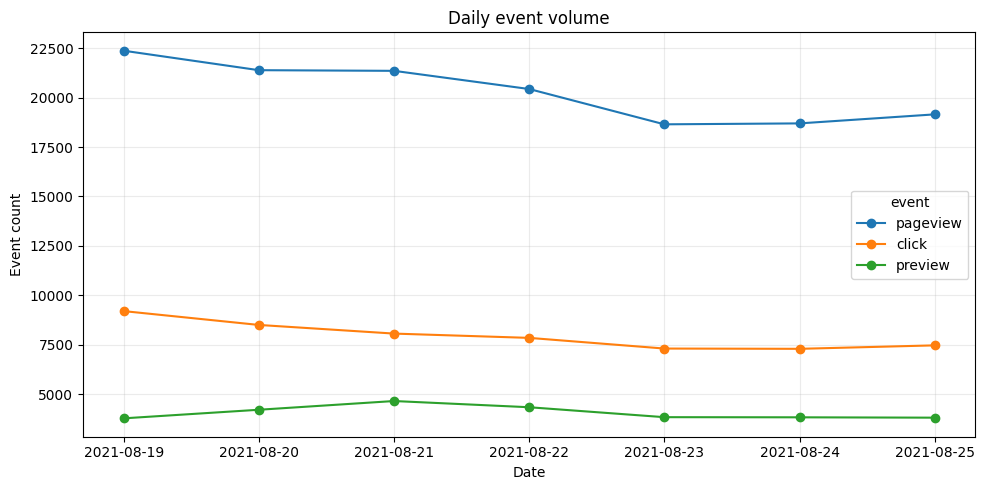

In [39]:
event_totals = (
    df["event"]
      .value_counts()
      .reindex(EXPECTED_EVENTS, fill_value=0)
      .rename("total_events")
      .to_frame()
)
event_totals["share_of_all_events"] = event_totals["total_events"] / len(df)

events_per_day = (
    df.groupby(["date", "event"], observed=True)
      .size()
      .unstack("event", fill_value=0)
      .reindex(columns=EXPECTED_EVENTS, fill_value=0)
)

display(event_totals)
display(Markdown("**Daily event distribution**"))
display(events_per_day)

ax = events_per_day.plot(kind="line", marker="o", figsize=(10, 5))
ax.set_title("Daily event volume")
ax.set_xlabel("Date")
ax.set_ylabel("Event count")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Question 3 — Countries that generated pageviews

The problem statement asks about **pageviews**, so this section filters `event == "pageview"`. The complete sorted distribution is stored in `pageviews_by_country`; the leading countries are displayed for readability.

Pageviews came from **211 non-null countries/territories**; **9 pageview rows** have a missing country.

,pageviews,share
country,,
Saudi Arabia,28873,0.2033
India,27286,0.1921
United States,20839,0.1467
France,9674,0.0681
Iraq,4897,0.0345
United Kingdom,3845,0.0271
Pakistan,3212,0.0226
Germany,3141,0.0221
Turkey,2462,0.0173


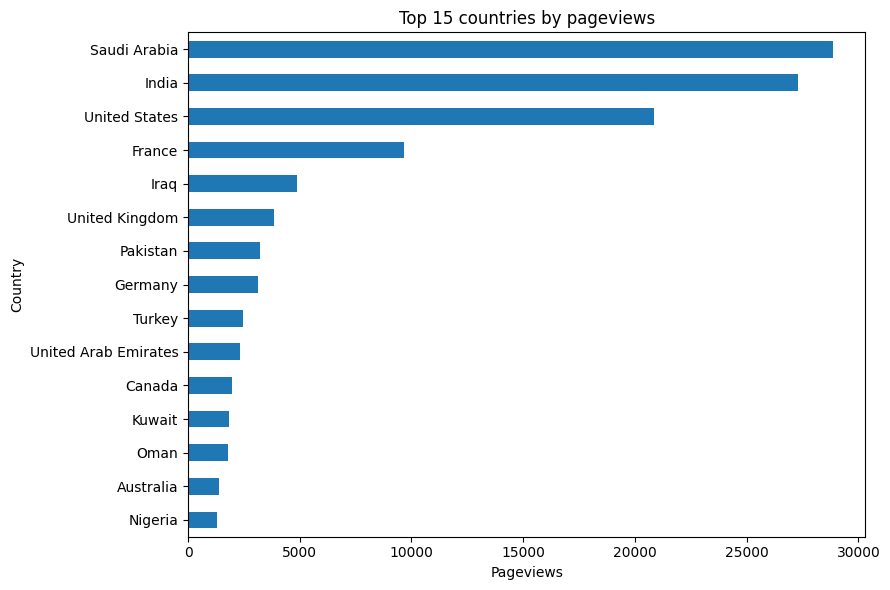

In [40]:
pageview_rows = df.loc[pageview_mask]

pageviews_by_country = (
    pageview_rows.dropna(subset=["country"])
                 .groupby("country", observed=True)
                 .size()
                 .rename("pageviews")
                 .sort_values(ascending=False)
                 .to_frame()
)
pageviews_by_country["share"] = pageviews_by_country["pageviews"] / pageview_total

country_count = pageviews_by_country.index.nunique()
missing_country_pageviews = int(pageview_rows["country"].isna().sum())

display(Markdown(
    f"Pageviews came from **{country_count:,} non-null countries/territories**; "
    f"**{missing_country_pageviews:,} pageview rows** have a missing country."
))
display(pageviews_by_country.head(20))

ax = pageviews_by_country.head(15).sort_values("pageviews").plot(
    kind="barh", y="pageviews", legend=False, figsize=(9, 6)
)
ax.set_title("Top 15 countries by pageviews")
ax.set_xlabel("Pageviews")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

## 6. Question 4 — Overall click rate

The overall click rate is the **ratio of total clicks to total pageviews**. It is a traffic-weighted aggregate and is not the same as the arithmetic mean of link-level rates.

In [41]:
click_total = int(df["event"].eq("click").sum())
preview_total = int(df["event"].eq("preview").sum())

if pageview_total == 0:
    raise ZeroDivisionError("Overall click rate is undefined because pageviews are zero.")

overall_click_rate = click_total / pageview_total
orphan_clicks = int(link_metrics.loc[~link_metrics["has_pageview"], "clicks"].sum())

click_rate_summary = pd.Series(
    {
        "total_clicks": click_total,
        "total_pageviews": pageview_total,
        "overall_click_rate": overall_click_rate,
        "overall_click_rate_percent": 100 * overall_click_rate,
        "clicks_on_links_without_pageviews": orphan_clicks,
    },
    name="value",
).to_frame()

display(click_rate_summary)
display(Markdown(
    f"**Overall click rate = {click_total:,} / {pageview_total:,} = "
    f"{overall_click_rate:.4f}, or {overall_click_rate:.2%}.**"
))

,value
total_clicks,"55,732.0000"
total_pageviews,"142,015.0000"
overall_click_rate,0.3924
overall_click_rate_percent,39.2437
clicks_on_links_without_pageviews,2.0000


**Overall click rate = 55,732 / 142,015 = 0.3924, or 39.24%.**

## 7. Question 5 — Distribution of click rate across links

For a valid per-link distribution:

1. start with every link that has at least one pageview;
2. retain zero-click links by treating their click count as zero;
3. exclude only links with zero pageviews because their rate has no denominator.

A rate above 1 is possible in event data because a link can record multiple click events per pageview. Therefore, this ratio should not automatically be interpreted as a unique-user conversion probability.

---

**Why analyze the full link-level distribution?**

The overall click rate answers, **“What fraction of all pageviews generated clicks?”** It can hide major differences between links because high-traffic links dominate the aggregate.

The link-level distribution answers a different business question: **“Is performance broadly consistent, or is it concentrated in a small group of links?”** We therefore inspect the median, percentiles, zero-click links, and extreme rates rather than relying on one average.


In [42]:
link_rates = link_metrics.loc[link_metrics["has_pageview"]].copy()

click_rate_distribution = link_rates["click_rate"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).rename("click_rate")

rate_diagnostics = pd.Series(
    {
        "links_in_distribution": len(link_rates),
        "links_with_zero_click_rate": int(link_rates["click_rate"].eq(0).sum()),
        "links_with_click_rate_equal_to_1": int(link_rates["click_rate"].eq(1).sum()),
        "links_with_click_rate_above_1": int(link_rates["click_rate"].gt(1).sum()),
        "unweighted_mean_link_rate": link_rates["click_rate"].mean(),
        "traffic_weighted_overall_rate": link_rates["clicks"].sum() / link_rates["pageviews"].sum(),
    },
    name="value",
).to_frame()

display(click_rate_distribution.to_frame())
display(rate_diagnostics)

,click_rate
count,"3,837.0000"
mean,0.4756
std,1.5524
min,0.0000
1%,0.0000
5%,0.0000
10%,0.0000
25%,0.0000
50%,0.3879
75%,1.0000


,value
links_in_distribution,"3,837.0000"
links_with_zero_click_rate,"1,584.0000"
links_with_click_rate_equal_to_1,"1,157.0000"
links_with_click_rate_above_1,54.0000
unweighted_mean_link_rate,0.4756
traffic_weighted_overall_rate,0.3924


---

**Why use two views of the skewed click-rate distribution?**

- **`99th-percentile` view:** keeps the x-axis in the original click-rate units, making the main body of links easy to interpret. The top 1% is temporarily omitted only from this plot—not from the analysis.
- **`log1p` view:** compresses the extreme right tail while retaining every link, including zero-click links because `log1p(0) = 0`.

Using both prevents two opposite mistakes: allowing a few extreme links to flatten the main histogram, or hiding those extreme links entirely.

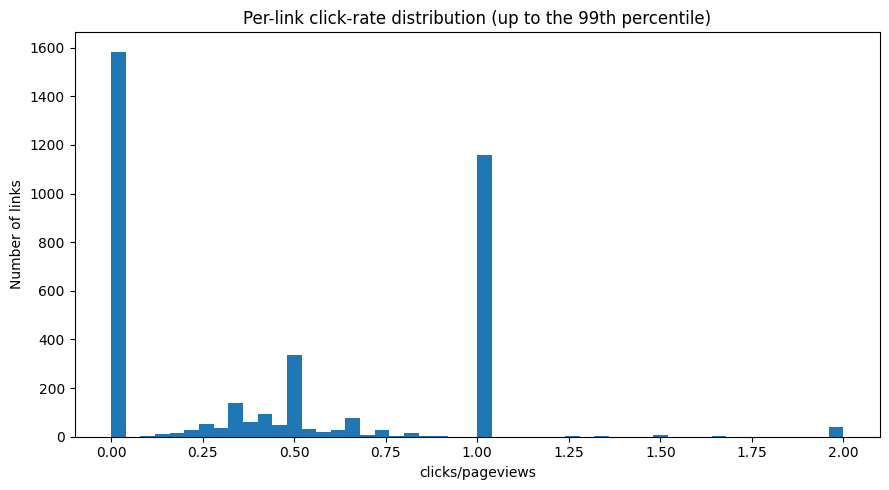

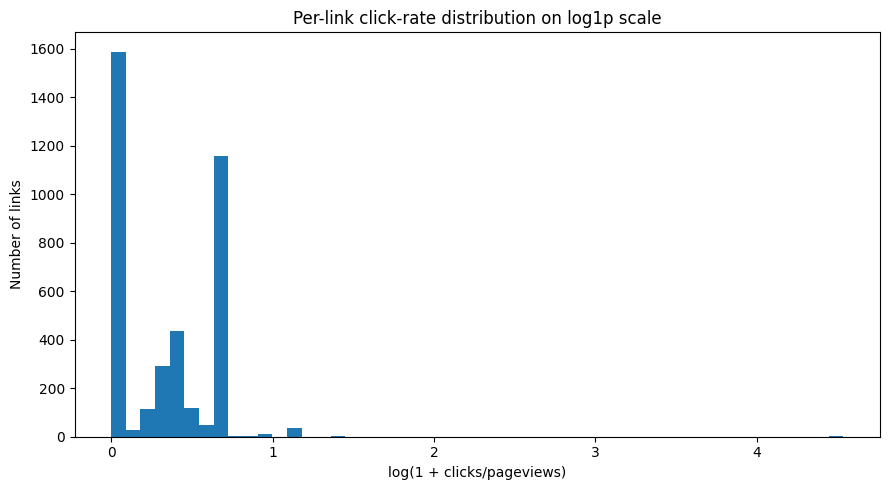

In [43]:
# Raw rates have an extreme right tail. The 99th percentile provides a readable main view.
upper_limit = link_rates["click_rate"].quantile(0.99)

fig, ax = plt.subplots(figsize=(9, 5))
link_rates.loc[link_rates["click_rate"].le(upper_limit), "click_rate"].plot(
    kind="hist", bins=50, ax=ax
)
ax.set_title("Per-link click-rate distribution (up to the 99th percentile)")
ax.set_xlabel("clicks/pageviews")
ax.set_ylabel("Number of links")
plt.tight_layout()
plt.show()


'''
Why use log1p(click_rate)?
- The raw click-rate distribution is strongly right-skewed with a few very large values.
- log1p(x) = log(1 + x) compresses large values, making the main distribution easier to see.
- It keeps zero values valid because log1p(0) = 0, unlike log(0), which is undefined.
- This plot retains all observations instead of removing values above the 99th percentile.
- The transformation changes the scale for visualization, not the ordering of click rates.
'''

fig, ax = plt.subplots(figsize=(9, 5))
np.log1p(link_rates["click_rate"]).plot(kind="hist", bins=50, ax=ax)
ax.set_title("Per-link click-rate distribution on log1p scale")
ax.set_xlabel("log(1 + clicks/pageviews)")
ax.set_ylabel("Number of links")
plt.tight_layout()
plt.show()

---

**Why test sensitivity to minimum pageviews?**

A rate based on very few pageviews is statistically unstable: one additional click can change it dramatically. A link with 1 pageview and 1 click has a 100% rate, but that estimate is much less reliable than a similar rate based on hundreds of pageviews.

The threshold table is a **sensitivity analysis**, not an attempt to select the most favorable cutoff. If the weighted rate and median remain reasonably stable as low-volume links are removed, the business conclusion is less dependent on noisy small denominators.

In [44]:
# Small denominators produce unstable per-link rates. Compare summaries at practical traffic thresholds.

'''
Unweighted mean click rate:
- Calculates each link's click rate, then averages the rates.
- Every link receives equal importance, regardless of its pageviews.
- Can be distorted by low-traffic links with extreme click rates.

Weighted mean click rate:
- Divides total clicks across all links by total pageviews.
- Links with more pageviews have a greater influence on the result.
- Represents the overall click-through rate across all pageviews.

As the minimum pageview threshold increases, the two rates become closer
because unstable click rates from low-traffic links are removed.
'''

threshold_rows = []
for minimum_pageviews in [1, 5, 10, 50, 100]:
    subset = link_rates.loc[link_rates["pageviews"].ge(minimum_pageviews)]
    threshold_rows.append(
        {
            "minimum_pageviews": minimum_pageviews,
            "links": len(subset),
            "median_click_rate": subset["click_rate"].median(),
            "unweighted_mean_click_rate": subset["click_rate"].mean(),
            "weighted_click_rate": subset["clicks"].sum() / subset["pageviews"].sum(),
        }
    )

threshold_sensitivity = pd.DataFrame(threshold_rows).set_index("minimum_pageviews")
display(threshold_sensitivity)

,links,median_click_rate,unweighted_mean_click_rate,weighted_click_rate
minimum_pageviews,,,,
1,3837,0.3879,0.4756,0.3924
5,571,0.4035,0.5803,0.3904
10,402,0.4000,0.6359,0.3899
50,235,0.3962,0.3955,0.3821
100,169,0.3975,0.3981,0.3818


## 8. Question 6 — Relationship between clicks and previews

The statistical unit must be a **link**, not an event row. Repeating a link's aggregate click and preview counts on every event row gives popular links disproportionate weight and inflates the apparent relationship.

We test four complementary questions:

1. **Pearson correlation:** Is there a linear relationship between raw click and preview counts?
2. **Spearman correlation:** Is there a monotonic relationship robust to skew and outliers?
3. **Binary association:** Are `has_click` and `has_preview` associated? We use a 2x2 table, chi-square/Fisher tests, phi, and the odds ratio.
4. **Traffic-normalized sensitivity:** Do click rate and preview rate move together after dividing both by pageviews? We also report a partial correlation of log counts controlling for pageviews.

These are observational associations; they do not establish that previews cause clicks.

---

**Statistical setup: what each test is actually asking**

Raw counts, ranks, binary indicators, and traffic-normalized rates answer different business questions. No single correlation is sufficient:

| Method | Business question | Main limitation |
|---|---|---|
| Pearson on raw counts | Do links with more previews tend to have proportionally more clicks? | Sensitive to skew, extreme high-volume links, and shared traffic volume |
| Pearson on `log1p` counts | Does the linear relationship remain after compressing extreme volumes? | Still measures association between counts and does not remove pageview exposure |
| Spearman correlation | Do links with more previews generally rank higher in clicks, even if the relationship is not linear? | Uses ordering rather than the size of count differences |
| Binary association | Are links with any previews more likely to record any clicks? | Discards event volume and traffic intensity |
| Rate/partial correlations | Does the relationship remain after accounting for pageview opportunity? | Reduces, but does not eliminate, observational confounding |

Throughout this section, a small p-value addresses **whether an association is statistically detectable**. The coefficient, phi, odds ratio, risk ratio, and confidence interval address **how large and practically relevant the association is**.

---

**Continuous association: Pearson versus Spearman**

**Business question:** Do links that accumulate more previews also accumulate more clicks?

**Why Pearson?** Pearson's `r` measures the strength of a **linear** relationship. It is useful if an increase in previews is associated with a roughly proportional increase in clicks.

- **H₀:** The population linear correlation between click and preview counts is zero (`ρ = 0`).
- **H₁:** The population linear correlation is not zero (`ρ ≠ 0`).

**Why Pearson on `log1p` counts?** Counts are highly right-skewed and a few popular links can dominate the raw-scale result. `log1p` compresses large counts and retains zeros. If the correlation remains strong, it is less likely to be explained only by a handful of extreme links.

**Why Spearman as well?** Spearman's `ρₛ` tests whether the relationship is **monotonic**: links with more previews generally have more clicks, without requiring proportional increases or normal data. It is less sensitive to outliers because it operates on ranks.

- **H₀:** There is no monotonic association between click and preview counts (`ρₛ = 0`).
- **H₁:** A monotonic association exists (`ρₛ ≠ 0`).

Pearson alone would be insufficient because a very high raw-count correlation can be created by shared popularity: high-traffic links naturally receive more of every event.

,coefficient,p_value,p_value_formatted,effect_magnitude
test,,,,
Pearson on raw counts,0.9887,0.0000,< 1e-300,large
Pearson on log1p counts,0.8809,0.0000,< 1e-300,large
Spearman rank correlation,0.5199,0.0000,6.15e-265,large


Pearson's raw-count correlation is **r = 0.989** (95% CI 0.988 to 0.989; p < 1e-300).

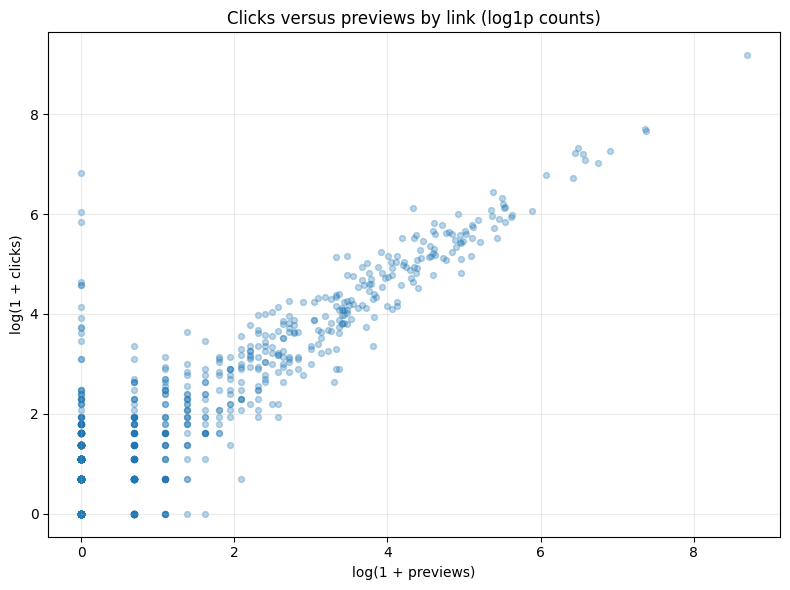

In [45]:
# Raw count correlations at link level
click_counts = link_metrics["clicks"].to_numpy()
preview_counts = link_metrics["previews"].to_numpy()
n_links = len(link_metrics)

pearson_result = stats.pearsonr(click_counts, preview_counts)
spearman_result = stats.spearmanr(click_counts, preview_counts)
log_pearson_result = stats.pearsonr(np.log1p(click_counts), np.log1p(preview_counts))
pearson_ci = pearson_confidence_interval(pearson_result.statistic, n_links)

raw_correlation_results = pd.DataFrame(
    [
        {
            "test": "Pearson on raw counts",
            "coefficient": pearson_result.statistic,
            "p_value": pearson_result.pvalue,
            "p_value_formatted": format_p_value(pearson_result.pvalue),
            "effect_magnitude": correlation_effect_label(pearson_result.statistic),
        },
        {
            "test": "Pearson on log1p counts",
            "coefficient": log_pearson_result.statistic,
            "p_value": log_pearson_result.pvalue,
            "p_value_formatted": format_p_value(log_pearson_result.pvalue),
            "effect_magnitude": correlation_effect_label(log_pearson_result.statistic),
        },
        {
            "test": "Spearman rank correlation",
            "coefficient": spearman_result.statistic,
            "p_value": spearman_result.pvalue,
            "p_value_formatted": format_p_value(spearman_result.pvalue),
            "effect_magnitude": correlation_effect_label(spearman_result.statistic),
        },
    ]
).set_index("test")

display(raw_correlation_results)
display(Markdown(
    f"Pearson's raw-count correlation is **r = {pearson_result.statistic:.3f}** "
    f"(95% CI {pearson_ci[0]:.3f} to {pearson_ci[1]:.3f}; "
    f"p {format_p_value(pearson_result.pvalue)})."
))
print('\n')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    np.log1p(link_metrics["previews"]),
    np.log1p(link_metrics["clicks"]),
    alpha=0.30,
    s=18,
)
ax.set_title("Clicks versus previews by link (log1p counts)")
ax.set_xlabel("log(1 + previews)")
ax.set_ylabel("log(1 + clicks)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Interpretation of the raw-count results**

- **Raw Pearson `r = 0.989`, p < 1e-300:** reject the null hypothesis. Click and preview counts have an extremely strong linear association on the original scale.
- **Log-Pearson `r = 0.881`, p < 1e-300:** the relationship remains strong after compressing extreme volumes, so it is not caused solely by one or two outlying links.
- **Spearman `ρₛ = 0.520`, p ≈ 6.15e-265:** links with more previews generally rank higher in clicks, but the rank relationship is much weaker than the raw Pearson result.

The large gap between raw Pearson and Spearman is important: **the apparent strength depends heavily on event magnitude and high-volume links**. These tests establish co-movement in link popularity; they do not show that generating a preview causes a click.

---

**Binary association: preview presence versus click presence**

**Business question:** Is a link that records at least one preview more likely to record at least one click?

Binarizing the variables changes the focus from event volume to **activation/co-occurrence**. This is relevant when the business question is whether preview-active links cross the threshold into receiving clicks at all.

- **H₀:** `has_preview` and `has_click` are independent.
- **H₁:** The two binary variables are associated.

**Why chi-square?** It tests independence in a 2×2 contingency table. Here the expected cell counts are comfortably above the usual minimum, so its approximation is appropriate.

**Why Fisher's exact test too?** Fisher provides an exact p-value and serves as a robustness check, especially useful for sparse tables. In this dataset it should lead to the same significance conclusion.

**Why phi, odds ratio, and risk ratio?** A p-value only says whether an association is detectable. Phi summarizes overall association strength; the odds ratio compares odds; and the risk ratio compares the more intuitive probabilities of observing a click.

In [46]:
# Binary relationship: whether a link has clicks and previews

'''
For a 2x2 table, phi is equivalent in magnitude to Cramér's V.
The odds ratio describes how much higher the odds of recording clicks are among links that recorded previews.
'''

binary_table = pd.crosstab(
    link_metrics["has_click"],
    link_metrics["has_preview"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

binary_table_display = binary_table.copy()
binary_table_display.index = ["No clicks", "Has clicks"]
binary_table_display.columns = ["No previews", "Has previews"]
display(binary_table_display)

table_array = binary_table.to_numpy()
chi2, chi2_p, _, expected = stats.chi2_contingency(table_array, correction=False)
fisher_odds_ratio, fisher_p = stats.fisher_exact(table_array)
phi_signed = float(np.corrcoef(
    link_metrics["has_click"].astype(int),
    link_metrics["has_preview"].astype(int),
)[0, 1])
phi = abs(phi_signed)
odds_ci = odds_ratio_confidence_interval(table_array)

click_probability_with_preview = binary_table.loc[True, True] / binary_table[True].sum()
click_probability_without_preview = binary_table.loc[True, False] / binary_table[False].sum()
risk_ratio = click_probability_with_preview / click_probability_without_preview

binary_results = pd.Series(
    {
        "chi_square": chi2,
        "chi_square_p_value": chi2_p,
        "phi_effect_size": phi_signed,
        "phi_magnitude": correlation_effect_label(phi),
        "fisher_exact_p_value": fisher_p,
        "odds_ratio": fisher_odds_ratio,
        "odds_ratio_95pct_ci_lower": odds_ci[0],
        "odds_ratio_95pct_ci_upper": odds_ci[1],
        "P(click | preview)": click_probability_with_preview,
        "P(click | no preview)": click_probability_without_preview,
        "risk_ratio": risk_ratio,
        "minimum_expected_cell_count": expected.min(),
    },
    name="value",
).to_frame()

display(binary_results)
display(Markdown(
    f"The binary association is statistically significant "
    f"(chi-square p {format_p_value(chi2_p)}), with **phi = {phi_signed:.3f}** "
    f"({correlation_effect_label(phi)} to moderate in magnitude). Links with previews had "
    f"**{fisher_odds_ratio:.2f} times the odds** of having clicks "
    f"(95% CI {odds_ci[0]:.2f}–{odds_ci[1]:.2f})."
))

,No previews,Has previews
No clicks,1553,31
Has clicks,1791,464


,value
chi_square,287.1977
chi_square_p_value,0.0000
phi_effect_size,0.2735
phi_magnitude,small
fisher_exact_p_value,0.0000
odds_ratio,12.9787
odds_ratio_95pct_ci_lower,8.9659
odds_ratio_95pct_ci_upper,18.7876
P(click | preview),0.9374
P(click | no preview),0.5356


The binary association is statistically significant (chi-square p 2.03e-64), with **phi = 0.274** (small to moderate in magnitude). Links with previews had **12.98 times the odds** of having clicks (95% CI 8.97–18.79).

**Interpretation of the binary results**

- The chi-square and Fisher p-values are extremely small, so we reject independence: preview presence and click presence are associated.
- `P(click | preview) = 93.7%` versus `P(click | no preview) = 53.6%`; the risk ratio of `1.75` means links with previews were about 75% more likely to have at least one click.
- The odds ratio is `12.98` (95% CI: `8.97–18.79`). This refers to **odds**, not a 12.98-times higher probability; the risk ratio is the more intuitive probability comparison.
- Phi is `0.274`, a small association by the stated thresholds. Thus the relationship is statistically clear, but preview presence alone does not fully separate clicked from non-clicked links.

This result still may reflect link popularity: a link with more traffic has more opportunities to record both at least one preview and at least one click.

---

**Traffic-normalized relationship**

**Business question:** Among links with pageview opportunities, is a higher preview intensity associated with a higher click intensity?

Raw counts are exposed to a major common driver: **pageviews**. A popular link can have many previews and clicks even when previews have no relationship with click efficiency. Dividing by pageviews asks whether the two event rates move together rather than whether total volumes move together.

For both rate correlations:

- **H₀:** Click rate and preview rate have zero association.
- **H₁:** Click rate and preview rate have a non-zero association.

Pearson tests a linear rate relationship; Spearman checks for any monotonic rate relationship. Using both protects against concluding “no relationship” merely because the pattern is nonlinear or affected by skew.

The partial-correlation analysis provides a second adjustment: it removes the relationship of log-clicks and log-previews with log-pageviews, then correlates what remains. It asks whether links that receive **more clicks than expected for their traffic** also receive **more previews than expected for their traffic**.

This adjustment reduces the popularity effect but does not create a causal estimate; unobserved link quality, placement, audience, and content may still influence both outcomes.

In [47]:
# Traffic-normalized sensitivity analysis

'''
Raw click and preview counts can be highly correlated simply because popular links receive more of every event.
The rate-based test asks whether links with more previews per pageview also have more clicks per pageview.
'''

rate_analysis = link_metrics.loc[link_metrics["has_pageview"]].copy()

rate_pearson = stats.pearsonr(rate_analysis["click_rate"], rate_analysis["preview_rate"])
rate_spearman = stats.spearmanr(rate_analysis["click_rate"], rate_analysis["preview_rate"])

# Partial correlation: residualize log1p(clicks) and log1p(previews)
# against log1p(pageviews), then correlate the residuals.
log_pageviews = np.log1p(rate_analysis["pageviews"].to_numpy())
design_matrix = np.column_stack([np.ones(len(rate_analysis)), log_pageviews])

log_clicks = np.log1p(rate_analysis["clicks"].to_numpy())
log_previews = np.log1p(rate_analysis["previews"].to_numpy())

click_coefficients = np.linalg.lstsq(design_matrix, log_clicks, rcond=None)[0]
preview_coefficients = np.linalg.lstsq(design_matrix, log_previews, rcond=None)[0]
click_residuals = log_clicks - design_matrix @ click_coefficients
preview_residuals = log_previews - design_matrix @ preview_coefficients
partial_result = stats.pearsonr(click_residuals, preview_residuals)

normalized_results = pd.DataFrame(
    [
        {
            "test": "Pearson: click rate vs preview rate",
            "coefficient": rate_pearson.statistic,
            "p_value": rate_pearson.pvalue,
            "p_value_formatted": format_p_value(rate_pearson.pvalue),
            "effect_magnitude": correlation_effect_label(rate_pearson.statistic),
        },
        {
            "test": "Spearman: click rate vs preview rate",
            "coefficient": rate_spearman.statistic,
            "p_value": rate_spearman.pvalue,
            "p_value_formatted": format_p_value(rate_spearman.pvalue),
            "effect_magnitude": correlation_effect_label(rate_spearman.statistic),
        },
        {
            "test": "Partial Pearson on log counts, controlling pageviews",
            "coefficient": partial_result.statistic,
            "p_value": partial_result.pvalue,
            "p_value_formatted": format_p_value(partial_result.pvalue),
            "effect_magnitude": correlation_effect_label(partial_result.statistic),
        },
    ]
).set_index("test")

display(normalized_results)

,coefficient,p_value,p_value_formatted,effect_magnitude
test,,,,
Pearson: click rate vs preview rate,-0.0164,0.3092,0.3092,negligible
Spearman: click rate vs preview rate,0.0100,0.5358,0.5358,negligible
"Partial Pearson on log counts, controlling pageviews",0.0664,0.0000,3.85e-05,negligible


**Interpretation of the traffic-normalized results**

- **Rate Pearson `r = -0.016`, p = 0.309:** fail to reject the null hypothesis; there is no evidence of a meaningful linear relationship between preview rate and click rate.
- **Rate Spearman `ρₛ = 0.010`, p = 0.536:** fail to reject the null hypothesis; there is also no evidence of a monotonic relationship.
- **Partial correlation `r = 0.066`, p ≈ 3.85e-05:** the association is statistically detectable but practically negligible. With thousands of links, even a tiny effect can produce a small p-value.

The contrast is the key business finding: the raw Pearson correlation is `0.989`, but traffic-normalized relationships are approximately zero. **Most of the raw association is therefore explained by shared traffic volume/popularity, not evidence that a higher preview rate improves click rate.**

A randomized experiment—or user/session-level funnel data with temporal ordering—would be needed to estimate whether increasing previews causes additional clicks.

---

## 9. Final insights and business interpretation

In [48]:
display(Markdown(f"""
### Results

1. **Pageviews:** The links received **{pageview_total:,} pageviews** across the seven-day period. The daily counts are shown in `pageviews_per_day`.
2. **Other events:** There were **{click_total:,} clicks** and **{preview_total:,} previews**. Their daily distribution is shown in `events_per_day`.
3. **Countries:** Pageviews came from **{country_count:,} non-null countries/territories**. The largest sources were **{', '.join(pageviews_by_country.head(5).index.tolist())}**.
4. **Overall click rate:** **{overall_click_rate:.2%}** ({click_total:,} clicks / {pageview_total:,} pageviews).
5. **Per-link click-rate distribution:** Across **{len(link_rates):,} links with pageviews**, the median was **{link_rates['click_rate'].median():.3f}**, **{int(link_rates['click_rate'].eq(0).sum()):,} links** had zero clicks, and **{int(link_rates['click_rate'].gt(1).sum()):,} links** had more than one click event per pageview. The distribution is strongly right-skewed and unstable for low-volume links.
6. **Clicks versus previews:**
   - Raw counts show a **very strong positive linear association**: Pearson **r = {pearson_result.statistic:.3f}**, p {format_p_value(pearson_result.pvalue)}.
   - The rank-based relationship is lower but still positive: Spearman **rho = {spearman_result.statistic:.3f}**, p {format_p_value(spearman_result.pvalue)}.
   - Preview presence and click presence are associated: **phi = {phi_signed:.3f}**, with an odds ratio of **{fisher_odds_ratio:.2f}**.
   - However, after normalizing by pageviews, click rate and preview rate are effectively unrelated: Pearson **r = {rate_pearson.statistic:.3f}** (p = {rate_pearson.pvalue:.3f}) and Spearman **rho = {rate_spearman.statistic:.3f}** (p = {rate_spearman.pvalue:.3f}). The partial correlation controlling for pageviews is **{partial_result.statistic:.3f}**, statistically detectable but practically negligible.

### Decision-oriented conclusion

Popular links accumulate both clicks and previews, which explains most of the strong raw-count correlation. The binary results show that links with any previews are also much more likely to have clicks, but the traffic-normalized tests provide **no meaningful evidence that a higher preview rate is associated with a higher click rate**. This observational dataset therefore supports a co-occurrence/popularity story, not a causal claim that increasing previews will increase clicks. A controlled experiment or user/session-level funnel data would be needed for that claim.
"""))



### Results

1. **Pageviews:** The links received **142,015 pageviews** across the seven-day period. The daily counts are shown in `pageviews_per_day`.
2. **Other events:** There were **55,732 clicks** and **28,531 previews**. Their daily distribution is shown in `events_per_day`.
3. **Countries:** Pageviews came from **211 non-null countries/territories**. The largest sources were **Saudi Arabia, India, United States, France, Iraq**.
4. **Overall click rate:** **39.24%** (55,732 clicks / 142,015 pageviews).
5. **Per-link click-rate distribution:** Across **3,837 links with pageviews**, the median was **0.388**, **1,584 links** had zero clicks, and **54 links** had more than one click event per pageview. The distribution is strongly right-skewed and unstable for low-volume links.
6. **Clicks versus previews:**
   - Raw counts show a **very strong positive linear association**: Pearson **r = 0.989**, p < 1e-300.
   - The rank-based relationship is lower but still positive: Spearman **rho = 0.520**, p 6.15e-265.
   - Preview presence and click presence are associated: **phi = 0.274**, with an odds ratio of **12.98**.
   - However, after normalizing by pageviews, click rate and preview rate are effectively unrelated: Pearson **r = -0.016** (p = 0.309) and Spearman **rho = 0.010** (p = 0.536). The partial correlation controlling for pageviews is **0.066**, statistically detectable but practically negligible.

### Decision-oriented conclusion

Popular links accumulate both clicks and previews, which explains most of the strong raw-count correlation. The binary results show that links with any previews are also much more likely to have clicks, but the traffic-normalized tests provide **no meaningful evidence that a higher preview rate is associated with a higher click rate**. This observational dataset therefore supports a co-occurrence/popularity story, not a causal claim that increasing previews will increase clicks. A controlled experiment or user/session-level funnel data would be needed for that claim.
